In [12]:
!pip install control numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
import control

print("Libraries imported successfully.")

Defaulting to user installation because normal site-packages is not writeable
Libraries imported successfully.


In [13]:
"""
USER INSTRUCTIONS:
1. Choose the system representation by setting 'use_state_space' to True or False.
2. Update the values for the Transfer Function (num, den) or State-Space (A, B, C, D) as needed.
"""

use_state_space = False # Set to True for State-Space, False for Transfer Function

# Default Transfer Function Input (Derived from data)
num_input = [1, 1]
den_input = [1, 2, 2]

# Default State-Space Input (Derived from data)
A_input = [[0, 1], [-2, -2]]
B_input = [[0], [1]]
C_input = [[1, 1]]
D_input = [[0]]

def validate_and_create_system():
    try:
        if not use_state_space:
            # Transfer Function Validation
            if len(num_input) == 0 or len(den_input) == 0:
                raise ValueError("Numerator and Denominator must contain at least one value.")
            sys = control.TransferFunction(num_input, den_input)
            print("System defined using Transfer Function.")
        else:
            # State-Space Validation
            A = np.array(A_input)
            B = np.array(B_input)
            C = np.array(C_input)
            D = np.array(D_input)
            
            if A.shape[0] != A.shape[1]:
                raise ValueError("Matrix A must be square.")
            if A.shape[0] != B.shape[0]:
                raise ValueError("Matrix A and B must have the same number of rows.")
            if A.shape[1] != C.shape[1]:
                raise ValueError("Matrix A and C must have the same number of columns.")
            
            sys = control.StateSpace(A, B, C, D)
            print("System defined using State-Space.")
        return sys
    except Exception as e:
        print(f"Error in system definition: {e}")
        return None

sys = validate_and_create_system()
print(sys)

System defined using Transfer Function.
<TransferFunction>: sys[15]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      s + 1
  -------------
  s^2 + 2 s + 2


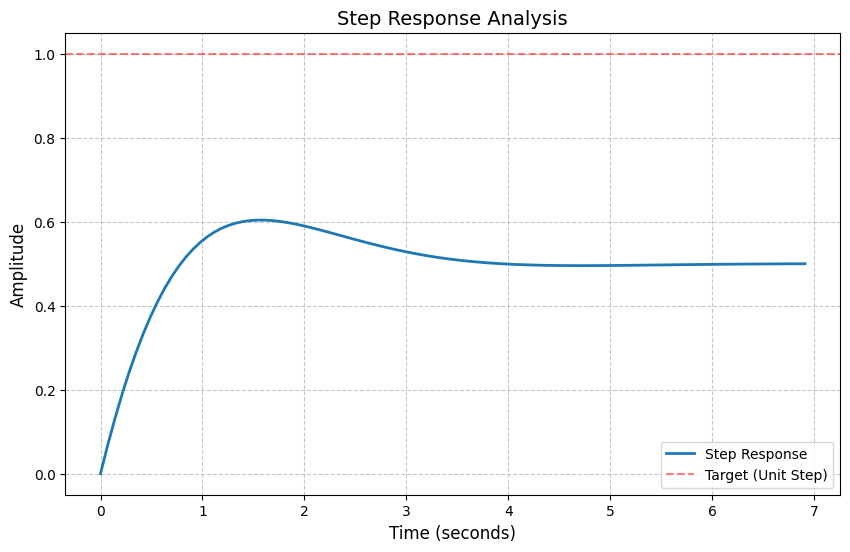

--- Step Response Metrics ---
Rise Time: 0.628 s
Settling Time: 3.489 s
Percent Overshoot: 20.764 %
Peak Value: 0.604


In [14]:
if sys is not None:
    # Calculate Step Response
    t, y = control.step_response(sys)
    
    # Calculate Step Metrics
    info = control.step_info(sys)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(t, y, label='Step Response', linewidth=2)
    plt.axhline(1, color='red', linestyle='--', alpha=0.5, label='Target (Unit Step)')
    plt.title('Step Response Analysis', fontsize=14)
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Amplitude', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()
    
    # Display Metrics
    print("--- Step Response Metrics ---")
    print(f"Rise Time: {info['RiseTime']:.3f} s")
    print(f"Settling Time: {info['SettlingTime']:.3f} s")
    print(f"Percent Overshoot: {info['Overshoot']:.3f} %")
    print(f"Peak Value: {info['Peak']:.3f}")
else:
    print("No valid system defined to perform step response analysis.")

In [15]:
if sys is not None:
    # Stability Analysis
    poles = control.pole(sys)
    zeros = control.zero(sys)
    is_stable = np.all(np.real(poles) < 0)
    
    # Plotting Pole-Zero Map
    plt.figure(figsize=(8, 8))
    ct.pzmap(sys, plot=True)
    plt.title('Pole-Zero Map', fontsize=14)
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.show()
    
    # Print Analysis
    print("--- Stability Analysis ---")
    print(f"Poles: {poles}")
    print(f"Zeros: {zeros}")
    if is_stable:
        print("Conclusion: The system is STABLE (all poles have negative real parts).")
    elif np.any(np.real(poles) > 0):
        print("Conclusion: The system is UNSTABLE (at least one pole has a positive real part).")
    else:
        print("Conclusion: The system is MARGINALLY STABLE (poles on the imaginary axis).")
else:
    print("No valid system defined to perform pole-zero analysis.")

AttributeError: module 'control' has no attribute 'pole'